In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


In [2]:
df = pd.read_csv(r"C:\Users\serag\Downloads\New folder (5)\weatherAUS.csv")
df.head()



,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)


<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
WindSpeed3pm      3062
Humidity9am       2654
WindSpeed9am      1767
Temp9am           1767
MinTemp           1485
MaxTemp           1261
Date                 0
Location             0
dtype: int64

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day


## Feature engineering

In [5]:
df['TempDiff'] = df['MaxTemp'] - df['MinTemp']
df['PressureDiff'] = df['Pressure3pm'] - df['Pressure9am']
df['HumidityDiff'] = df['Humidity3pm'] - df['Humidity9am']

def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    elif month in [9, 10, 11]:
        return "Spring"

df["Season"] = df["Month"].apply(get_season)



In [6]:
df['RainTomorrow'] = df['RainTomorrow'].map({'No':0,'Yes':1})
df['RainToday'] = df['RainToday'].map({'No':0,'Yes':1})


In [7]:
df['Humidity_bin'] = pd.cut(df['Humidity3pm'], bins=5)
df['Pressure_bin'] = pd.cut(df['Pressure3pm'], bins=5)

df['MaxTemp'] = df['MaxTemp'].fillna(
    df.groupby(['Season','Humidity_bin','Pressure_bin'])['MaxTemp']
      .transform('mean')
)

df['MaxTemp'] = df['MaxTemp'].fillna(
    df.groupby('Season')['MaxTemp'].transform('mean')
)

df['MaxTemp'] = df['MaxTemp'].fillna(df['MaxTemp'].mean())

df.drop(['Humidity_bin','Pressure_bin'], axis=1, inplace=True)


In [8]:
df.to_csv("clean_weather.csv", index=False)


## Rain by month

In [9]:
monthly_rain = df.groupby("Month")["RainTomorrow"].mean().reset_index()

fig = px.line(monthly_rain, x='Month', y='RainTomorrow',
              title="Rain Probability by Month")
fig.show()


## Humidity vs Rain

In [10]:
fig = px.box(df, x='RainTomorrow', y='Humidity3pm',
             title="Humidity vs RainTomorrow")
fig.show()


Rain Heatmap by Month & Location

In [11]:
heat_data = df.pivot_table(
    values="RainTomorrow",
    index="Location",
    columns="Month",
    aggfunc="mean"
)

import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
    z=heat_data.values,
    x=heat_data.columns,
    y=heat_data.index,
))

fig.update_layout(title="Rain Probability Heatmap")
fig.show()


In [12]:
fig = px.scatter_3d(
    df.sample(5000),
    x="Humidity3pm",
    y="Pressure3pm",
    z="Temp3pm",
    color="RainTomorrow"
)

fig.show()


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# نستخدم النسخة النظيفة
df_ml = df.copy()

# نشيل Date لأنها مش مفيدة مباشرة
df_ml = df_ml.drop(["Date"], axis=1)

# نحول الأعمدة النصية لـ One-Hot Encoding
df_ml = pd.get_dummies(df_ml, drop_first=True)

# نشيل أي NaN لو موجود
df_ml = df_ml.dropna()

# نفصل الهدف
X = df_ml.drop("RainTomorrow", axis=1)
y = df_ml["RainTomorrow"]

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8522981580306421


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8559993114133242
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91      9059
         1.0       0.76      0.50      0.61      2559

    accuracy                           0.86     11618
   macro avg       0.82      0.73      0.76     11618
weighted avg       0.85      0.86      0.84     11618



In [18]:
import joblib

joblib.dump(rf_model, "rain_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

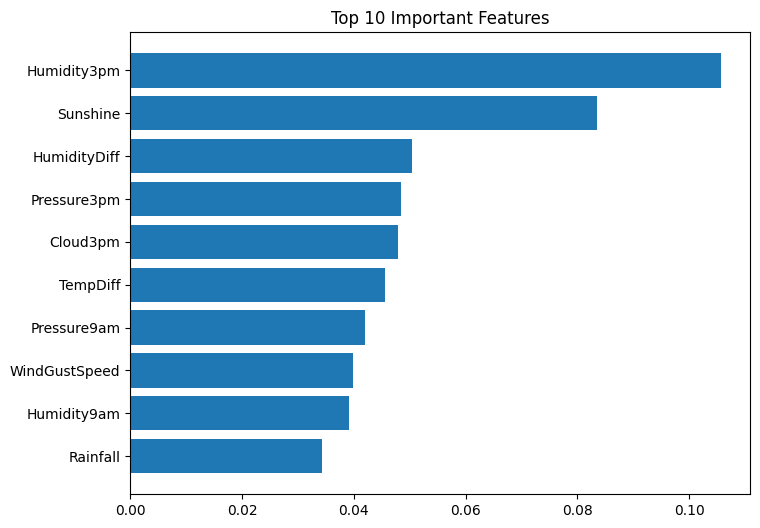

In [17]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,6))
plt.title("Top 10 Important Features")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.show()

In [20]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output, State
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import joblib

# ---------------- Load Data ---------------- #
df = pd.read_csv("clean_weather.csv")
df["Date"] = pd.to_datetime(df["Date"])

if "Year" not in df.columns:
    df["Year"] = df["Date"].dt.year
if "Month" not in df.columns:
    df["Month"] = df["Date"].dt.month

# ---------------- Load ML Model ---------------- #
model = joblib.load("rain_model.pkl")
model_columns = joblib.load("model_columns.pkl")

# ---------------- App Setup ---------------- #
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])

# ---------------- Layout ---------------- #
app.layout = dbc.Container([

    html.H1("🌦 Advanced Weather Analytics & ML Prediction",
            className="text-center my-4"),

    # ================= ML Prediction Section ================= #
    dbc.Card([
        dbc.CardBody([
            html.H4("🔮 Predict Rain Tomorrow"),

            dbc.Row([
                dbc.Col(dcc.Input(id="humidity_input", type="number",
                                  placeholder="Humidity 3PM"), width=3),

                dbc.Col(dcc.Input(id="pressure_input", type="number",
                                  placeholder="Pressure 3PM"), width=3),

                dbc.Col(dcc.Input(id="sunshine_input", type="number",
                                  placeholder="Sunshine Hours"), width=3),

                dbc.Col(dcc.Input(id="temp_input", type="number",
                                  placeholder="Temp 3PM"), width=3),
            ], className="mb-3"),

            dbc.Button("Predict", id="predict_btn",
                       color="primary", className="mb-3"),

            html.H3(id="prediction_output")

        ])
    ], className="mb-4"),

    html.Hr(),

    # -------- Filters -------- #
    dbc.Row([

        dbc.Col(
            dcc.Dropdown(
                id="location_filter",
                options=[{"label": i, "value": i} for i in sorted(df["Location"].unique())],
                multi=True,
                placeholder="Select Location"
            ),
            width=4
        ),

        dbc.Col(
            dcc.Dropdown(
                id="year_filter",
                options=[{"label": int(y), "value": int(y)} for y in sorted(df["Year"].unique())],
                multi=True,
                placeholder="Select Year"
            ),
            width=4
        ),

        dbc.Col(
            dcc.DatePickerRange(
                id="date_range",
                start_date=df["Date"].min(),
                end_date=df["Date"].max(),
                display_format="YYYY-MM-DD"
            ),
            width=4
        )

    ], className="mb-4"),

    # -------- KPI Cards -------- #
    dbc.Row([

        dbc.Col(dbc.Card(dbc.CardBody([
            html.H5("Total Records"),
            html.H2(id="total_records")
        ])), width=3),

        dbc.Col(dbc.Card(dbc.CardBody([
            html.H5("Rain Probability %"),
            html.H2(id="rain_prob")
        ])), width=3),

        dbc.Col(dbc.Card(dbc.CardBody([
            html.H5("Avg Temp (3PM)"),
            html.H2(id="avg_temp")
        ])), width=3),

        dbc.Col(dbc.Card(dbc.CardBody([
            html.H5("Avg Humidity (3PM)"),
            html.H2(id="avg_humidity")
        ])), width=3),

    ], className="mb-4"),

    # -------- Charts -------- #
    dbc.Row([
        dbc.Col(dcc.Graph(id="time_series"), width=6),
        dbc.Col(dcc.Graph(id="heatmap"), width=6),
    ]),

    dbc.Row([
        dbc.Col(dcc.Graph(id="scatter_plot"), width=6),
        dbc.Col(dcc.Graph(id="boxplot"), width=6),
    ])

], fluid=True)

# ================= Dashboard Callback ================= #
@app.callback(
    [
        Output("total_records", "children"),
        Output("rain_prob", "children"),
        Output("avg_temp", "children"),
        Output("avg_humidity", "children"),
        Output("time_series", "figure"),
        Output("heatmap", "figure"),
        Output("scatter_plot", "figure"),
        Output("boxplot", "figure"),
    ],
    [
        Input("location_filter", "value"),
        Input("year_filter", "value"),
        Input("date_range", "start_date"),
        Input("date_range", "end_date"),
    ]
)
def update_dashboard(locations, years, start_date, end_date):

    filtered = df.copy()

    if locations:
        filtered = filtered[filtered["Location"].isin(locations)]

    if years:
        filtered = filtered[filtered["Year"].isin(years)]

    filtered = filtered[
        (filtered["Date"] >= start_date) &
        (filtered["Date"] <= end_date)
    ]

    total_records = len(filtered)
    rain_prob = round(filtered["RainTomorrow"].mean() * 100, 2) if len(filtered) else 0
    avg_temp = round(filtered["Temp3pm"].mean(), 2) if len(filtered) else 0
    avg_humidity = round(filtered["Humidity3pm"].mean(), 2) if len(filtered) else 0

    ts = filtered.groupby("Date")["RainTomorrow"].mean().reset_index()
    fig_ts = px.line(ts, x="Date", y="RainTomorrow",
                     title="Rain Probability Over Time")

    heat_data = filtered.pivot_table(
        values="RainTomorrow",
        index="Location",
        columns="Month",
        aggfunc="mean"
    )

    fig_heat = go.Figure(data=go.Heatmap(
        z=heat_data.values,
        x=heat_data.columns,
        y=heat_data.index,
        colorscale="Blues"
    ))

    fig_heat.update_layout(title="Rain Probability Heatmap")

    sample_df = filtered.sample(min(3000, len(filtered))) if len(filtered) > 0 else filtered

    fig_scatter = px.scatter(
        sample_df,
        x="Humidity3pm",
        y="Pressure3pm",
        color="RainTomorrow",
        title="Humidity vs Pressure"
    )

    fig_box = px.box(
        filtered,
        x="RainTomorrow",
        y="Temp3pm",
        title="Temperature Distribution by Rain"
    )

    return (
        total_records,
        f"{rain_prob}%",
        avg_temp,
        avg_humidity,
        fig_ts,
        fig_heat,
        fig_scatter,
        fig_box
    )

# ================= Prediction Callback ================= #
@app.callback(
    Output("prediction_output", "children"),
    Input("predict_btn", "n_clicks"),
    State("humidity_input", "value"),
    State("pressure_input", "value"),
    State("sunshine_input", "value"),
    State("temp_input", "value"),
)
def predict_rain(n_clicks, humidity, pressure, sunshine, temp):

    if n_clicks is None:
        return ""

    if None in [humidity, pressure, sunshine, temp]:
        return "⚠ Please enter all values."

    input_dict = {col: 0 for col in model_columns}

    if "Humidity3pm" in input_dict:
        input_dict["Humidity3pm"] = humidity
    if "Pressure3pm" in input_dict:
        input_dict["Pressure3pm"] = pressure
    if "Sunshine" in input_dict:
        input_dict["Sunshine"] = sunshine
    if "Temp3pm" in input_dict:
        input_dict["Temp3pm"] = temp

    input_df = pd.DataFrame([input_dict])

    prediction = model.predict(input_df)[0]

    return "🌧 Rain Expected Tomorrow!" if prediction == 1 else "☀ No Rain Tomorrow."

# ---------------- Run App ---------------- #
if __name__ == "__main__":
    app.run(debug=True)

In [ ]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# ---------------- Load Data ---------------- #
df = pd.read_csv("clean_weather.csv")
df["Date"] = pd.to_datetime(df["Date"])

# لو Year و Month مش موجودين
if "Year" not in df.columns:
    df["Year"] = df["Date"].dt.year
if "Month" not in df.columns:
    df["Month"] = df["Date"].dt.month

# ---------------- App Setup ---------------- #
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])

# ---------------- Layout ---------------- #
app.layout = dbc.Container([

    html.H1("🌦 Advanced Weather Analytics Dashboard",
            className="text-center my-4"),

    # -------- Filters -------- #
    dbc.Row([

        dbc.Col(
            dcc.Dropdown(
                id="location_filter",
                options=[{"label": i, "value": i} for i in sorted(df["Location"].unique())],
                multi=True,
                placeholder="Select Location"
            ),
            width=4
        ),

        dbc.Col(
            dcc.Dropdown(
                id="year_filter",
                options=[{"label": int(y), "value": int(y)} for y in sorted(df["Year"].unique())],
                multi=True,
                placeholder="Select Year"
            ),
            width=4
        ),

        dbc.Col(
            dcc.DatePickerRange(
                id="date_range",
                start_date=df["Date"].min(),
                end_date=df["Date"].max(),
                display_format="YYYY-MM-DD"
            ),
            width=4
        )

    ], className="mb-4"),

    # -------- KPI Cards -------- #
    dbc.Row([

        dbc.Col(dbc.Card(dbc.CardBody([
            html.H5("Total Records"),
            html.H2(id="total_records")
        ])), width=3),

        dbc.Col(dbc.Card(dbc.CardBody([
            html.H5("Rain Probability %"),
            html.H2(id="rain_prob")
        ])), width=3),

        dbc.Col(dbc.Card(dbc.CardBody([
            html.H5("Avg Temp (3PM)"),
            html.H2(id="avg_temp")
        ])), width=3),

        dbc.Col(dbc.Card(dbc.CardBody([
            html.H5("Avg Humidity (3PM)"),
            html.H2(id="avg_humidity")
        ])), width=3),

    ], className="mb-4"),

    # -------- Charts Row 1 -------- #
    dbc.Row([
        dbc.Col(dcc.Graph(id="time_series"), width=6),
        dbc.Col(dcc.Graph(id="heatmap"), width=6),
    ]),

    # -------- Charts Row 2 -------- #
    dbc.Row([
        dbc.Col(dcc.Graph(id="scatter_plot"), width=6),
        dbc.Col(dcc.Graph(id="boxplot"), width=6),
    ])

], fluid=True)

# ---------------- Callback ---------------- #
@app.callback(
    [
        Output("total_records", "children"),
        Output("rain_prob", "children"),
        Output("avg_temp", "children"),
        Output("avg_humidity", "children"),
        Output("time_series", "figure"),
        Output("heatmap", "figure"),
        Output("scatter_plot", "figure"),
        Output("boxplot", "figure"),
    ],
    [
        Input("location_filter", "value"),
        Input("year_filter", "value"),
        Input("date_range", "start_date"),
        Input("date_range", "end_date"),
    ]
)
def update_dashboard(locations, years, start_date, end_date):

    filtered = df.copy()

    if locations:
        filtered = filtered[filtered["Location"].isin(locations)]

    if years:
        filtered = filtered[filtered["Year"].isin(years)]

    filtered = filtered[
        (filtered["Date"] >= start_date) &
        (filtered["Date"] <= end_date)
    ]

    # ----- KPIs -----
    total_records = len(filtered)
    rain_prob = round(filtered["RainTomorrow"].mean() * 100, 2) if len(filtered) else 0
    avg_temp = round(filtered["Temp3pm"].mean(), 2) if len(filtered) else 0
    avg_humidity = round(filtered["Humidity3pm"].mean(), 2) if len(filtered) else 0

    # ----- Time Series -----
    ts = filtered.groupby("Date")["RainTomorrow"].mean().reset_index()
    fig_ts = px.line(ts, x="Date", y="RainTomorrow",
                     title="Rain Probability Over Time")

    # ----- Heatmap -----
    heat_data = filtered.pivot_table(
        values="RainTomorrow",
        index="Location",
        columns="Month",
        aggfunc="mean"
    )

    fig_heat = go.Figure(data=go.Heatmap(
        z=heat_data.values,
        x=heat_data.columns,
        y=heat_data.index,
        colorscale="Blues"
    ))

    fig_heat.update_layout(title="Rain Probability Heatmap")

    # ----- Scatter -----
    sample_df = filtered.sample(min(3000, len(filtered))) if len(filtered) > 0 else filtered

    fig_scatter = px.scatter(
        sample_df,
        x="Humidity3pm",
        y="Pressure3pm",
        color="RainTomorrow",
        title="Humidity vs Pressure"
    )

    # ----- Boxplot -----
    fig_box = px.box(
        filtered,
        x="RainTomorrow",
        y="Temp3pm",
        title="Temperature Distribution by Rain"
    )

    return (
        total_records,
        f"{rain_prob}%",
        avg_temp,
        avg_humidity,
        fig_ts,
        fig_heat,
        fig_scatter,
        fig_box
    )

# ---------------- Run App ---------------- #
if __name__ == "__main__":
    app.run(debug=True)
